In [1]:
import torch
import torch.nn as nn
import json
import os
import pandas as pd
from models.lstm import LSTM as LSTM1
from models.lstm_proj_diff import LSTM as LSTM2
from utils.dataset import TranslateDataset
from torch.utils.data import DataLoader
import tokenizers
import numpy as np
from tqdm import tqdm

In [2]:
df_eval = pd.read_parquet("data/tokenized_eval.parquet")
df_train = pd.read_parquet("data/tokenized_train_amostrado.parquet")

In [3]:
tokenizer = tokenizers.Tokenizer.from_file("artifacts/tokenizer_50000.json")

In [4]:
dataset_eval = TranslateDataset(
    tokens_src=df_train['en_tokens_50000'].tolist(),
    tokens_tgt=df_train['pt_tokens_50000'].tolist(),
    invert_src=True
)

dataloader_eval = DataLoader(dataset_eval, batch_size=64, shuffle=False)

In [5]:
MODELS_TRY = [
    LSTM2
]

In [6]:
PATH_MODELS = "artifacts"

models = {}
for file in os.listdir(PATH_MODELS):
    if file.endswith(".pt"):
        model_name = file.split(".")[0].replace('model_', '')
        if('v33' not in model_name):
           continue
        print(f'Lendo {model_name}')
        model_path = os.path.join(PATH_MODELS, file)
        model_config_path = os.path.join("configs", f"{model_name}_config.json")
        
        with open(model_config_path, 'r', encoding='utf-8') as f:
            model_config = json.load(f)
        
        for MODEL_TRY in MODELS_TRY:
            try:
                model = MODEL_TRY(embedding_dim=model_config["embedding_dim"],
                            encoder_bidirectional=model_config["encoder_bidirectional"],
                            encoder_hidden_dim=model_config["encoder_hidden_dim"],
                            encoder_num_layers=model_config["encoder_num_layers"],
                            decoder_hidden_dim=model_config["decoder_hidden_dim"],
                            decoder_num_layers=model_config["decoder_num_layers"],
                            encoder_dropout=model_config["encoder_dropout"],
                            decoder_dropout=model_config["decoder_dropout"],
                            vocab_size=model_config["vocab_size"] if "vocab_size" in model_config else 10000, 
                            pad_idx=0)
                model.load_state_dict(torch.load(model_path))
                model.to("cuda" if torch.cuda.is_available() else "cpu")
                model.eval()
                models[model_name] = model
                break
            except RuntimeError as e:
                print(str(e))
                continue

Lendo v33_amostrado


/media/alvarinho/dados/Estudos/traducao-rede-neural/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.4 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
/media/alvarinho/dados/Estudos/traducao-rede-neural/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:1061: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


In [7]:
print(models.keys())

dict_keys(['v33_amostrado'])


In [8]:
for model_name, model in models.items():

    print(f"Model: {model_name}")

    decoded_outputs = []

    for batch in tqdm(dataloader_eval):

        enc_tokens, _ = batch

        enc_tokens = enc_tokens.to('cuda')
        

        with torch.no_grad():

            outputs = model.predict(
                src=enc_tokens,
                bos_token_id=5,
                eos_token_id=6,
                max_len=64
            )

        decoded_outputs.extend(
            tokenizer.decode_batch(
                outputs.cpu().tolist(),
                skip_special_tokens=True
            )
        )

    df_train[f'{model_name}_pred'] = decoded_outputs

Model: v33_amostrado


100%|██████████| 2/2 [00:00<00:00, 10.64it/s]


In [9]:
model_name

'v33_amostrado'

In [12]:
df_configs = pd.DataFrame([json.load(open(os.path.join("configs", f))) for f in os.listdir("configs") if f.endswith("_config.json")])
df_configs.loc[df_configs['name'].isin(models.keys())].to_dict(orient='records')

[{'invert_src': False,
  'embedding_dim': 384,
  'encoder_hidden_dim': 512,
  'decoder_hidden_dim': 512,
  'encoder_num_layers': 1,
  'decoder_num_layers': 1,
  'encoder_dropout': 0.4,
  'decoder_dropout': 0.4,
  'encoder_bidirectional': True,
  'batch_size': 128,
  'accum_steps': 1,
  'log_steps': 250,
  'save_steps': 1000,
  'eval_steps': 500,
  'device': 'cuda',
  'desc': 'Treinando somente com 100 observações',
  'name': 'v33_amostrado',
  'early_stop_patience': 50000,
  'early_stop_min_delta': 0.0,
  'warmup_steps': 25000.0,
  'max_steps': 500000.0,
  'learning_rate': 0.0001,
  'vocab_size': 50000.0}]

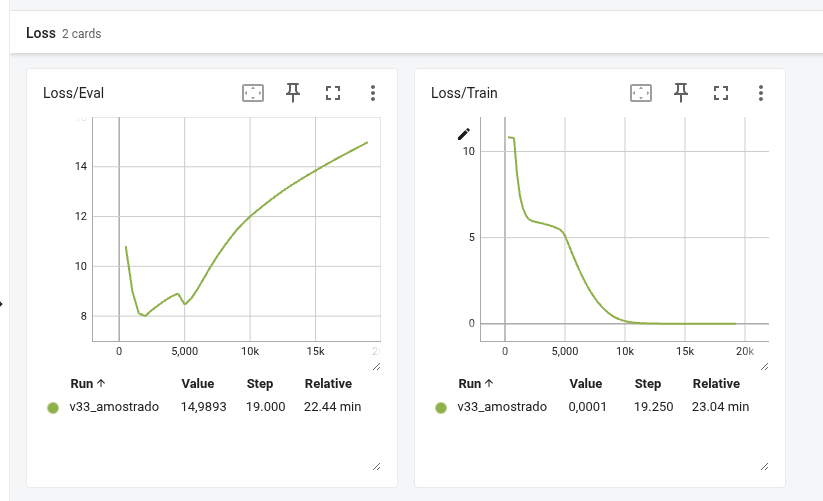

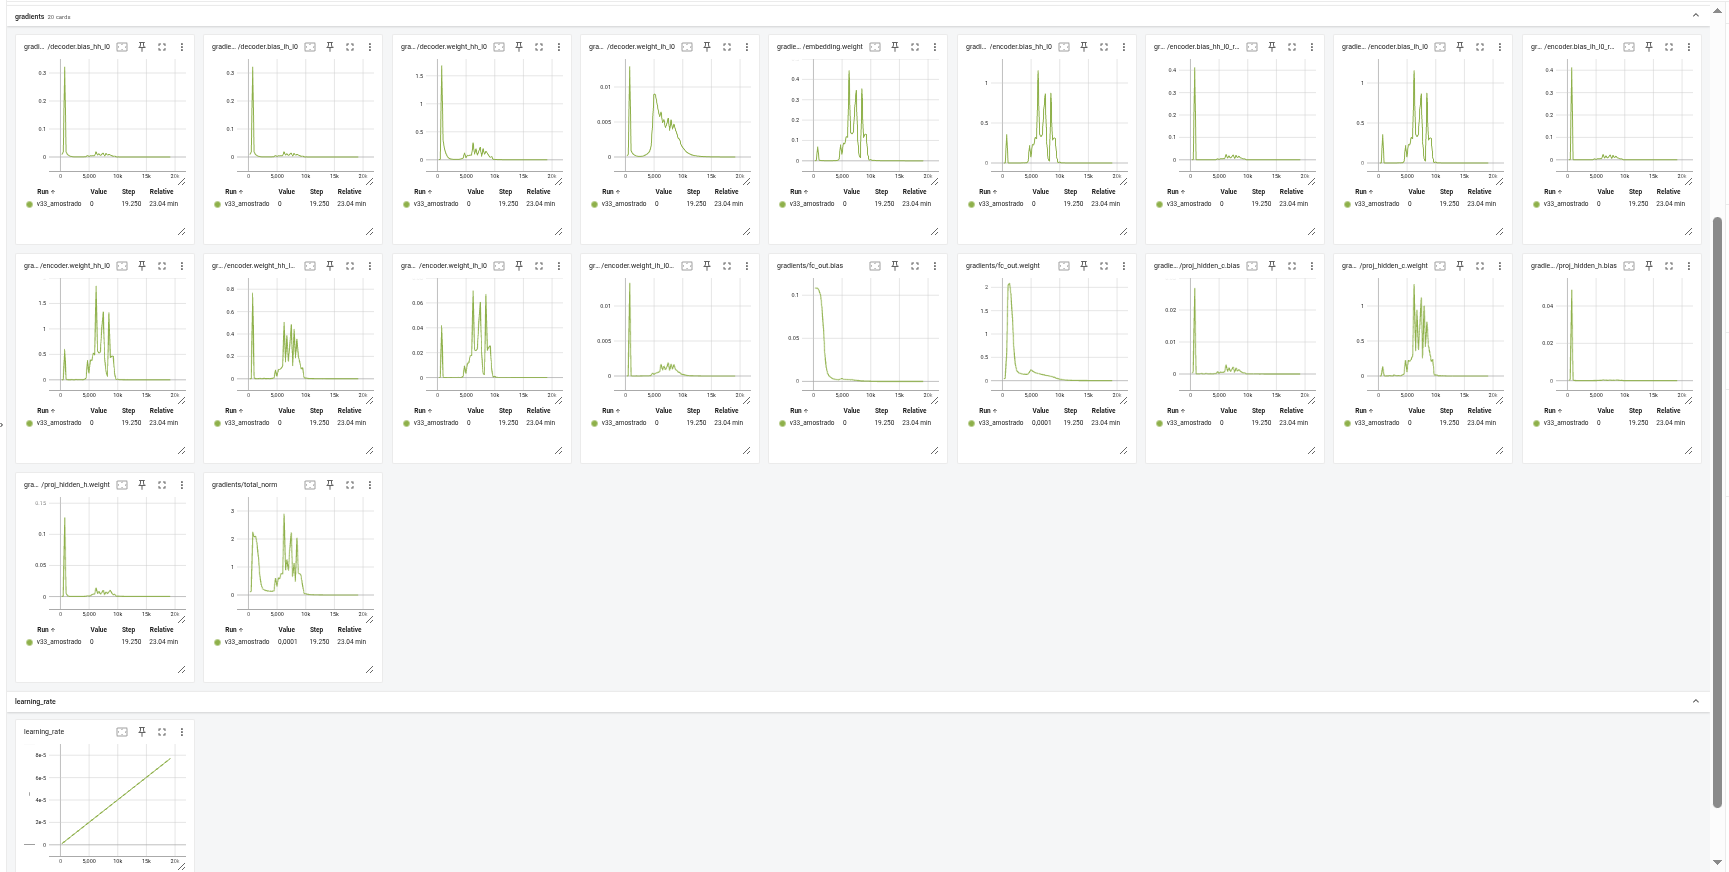

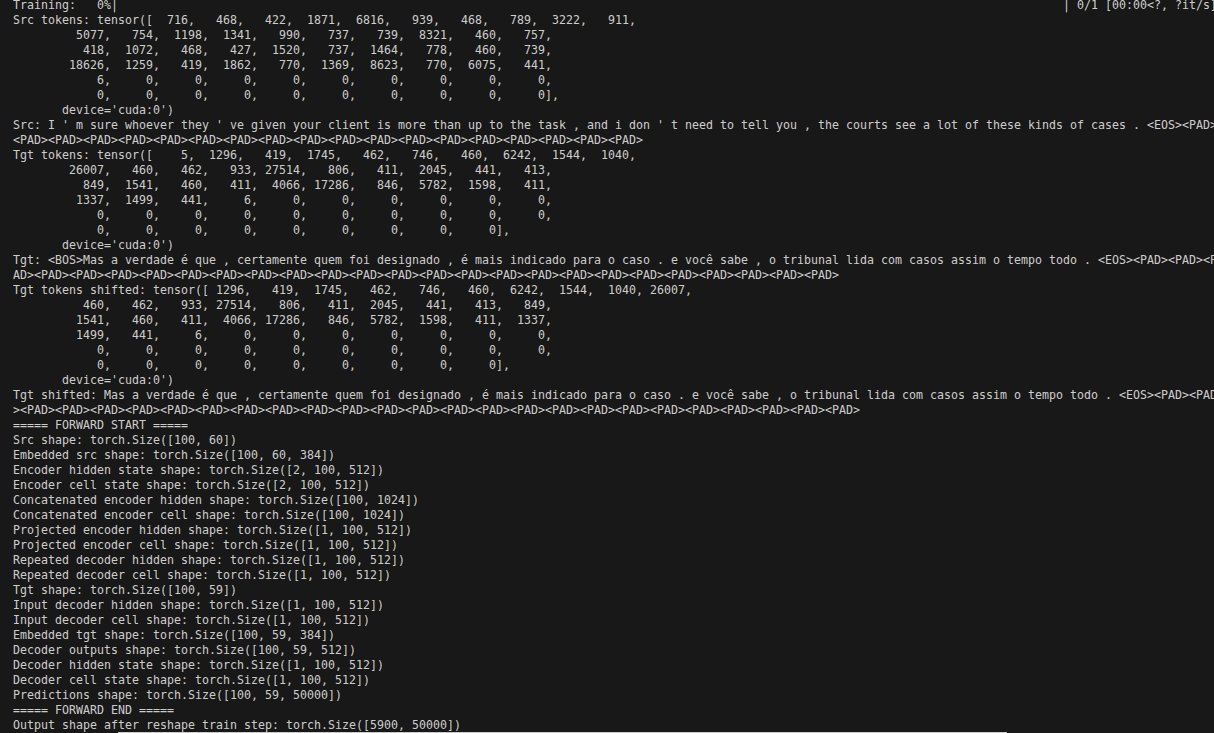

In [13]:
df_train.head()

,en,pt,en_length,pt_length,en_max_len_word,pt_max_len_word,en_tokens_10000,pt_tokens_10000,en_tokens_50000,pt_tokens_50000,v33_amostrado_pred
0,Am i correct in assuming that your attempt to ...,Estou correto em dizer que sua tentativa de se...,152,159,10,12,"[5, 36, 419, 430, 8442, 781, 5904, 753, 790, 9...","[5, 2950, 2702, 737, 762, 1344, 746, 973, 6826...","[5, 37235, 418, 8442, 781, 14510, 790, 911, 71...","[5, 2950, 12064, 762, 1344, 746, 973, 6826, 74...",Era pequeno e crescia em uma floresta coberta ...
1,This feeling that the world has finally caught...,Este sentimento de que o mundo... finalmente e...,103,108,7,10,"[5, 2023, 3822, 790, 739, 1431, 1013, 3397, 48...","[5, 4417, 7580, 740, 746, 416, 1400, 776, 3704...","[5, 2023, 3822, 790, 739, 1431, 1013, 3397, 48...","[5, 4417, 7580, 740, 746, 411, 1400, 776, 3704...",Este sentimento de que o mundo ... finalmente ...
2,"Senator santorum, you said that your campaign ...","Senador santorum, você disse que sua campanha ...",164,154,13,9,"[5, 4669, 2806, 86, 976, 743, 799, 443, 778, 1...","[5, 4669, 1737, 86, 976, 743, 799, 443, 849, 1...","[5, 37719, 20116, 743, 799, 460, 778, 1479, 79...","[5, 4669, 1737, 20116, 743, 799, 460, 849, 135...","Senador santorum , você disse que vai pegar o ..."
3,"My fellow councillors, i've asked you to assem...","Meus colegas conselheiros, pedi para que viess...",130,133,12,13,"[5, 2430, 7270, 1485, 70, 4028, 2345, 443, 430...","[5, 5701, 896, 6650, 3717, 5504, 443, 6876, 80...","[5, 2430, 7270, 47649, 2345, 460, 418, 468, 78...","[5, 10320, 6650, 28985, 460, 6876, 806, 746, 3...","Senador santorum , e disse que sua campanha é ..."
4,But i believe the time is right for me to stan...,Mas eu acredito que é o momento certo para eu ...,107,102,10,12,"[5, 1300, 430, 1978, 739, 1066, 754, 1269, 855...","[5, 1296, 845, 4387, 746, 453, 416, 2095, 2157...","[5, 1300, 418, 1978, 739, 1066, 754, 1269, 855...","[5, 1296, 845, 4387, 746, 462, 411, 2095, 2157...",Ele era bastante inconsistente quando calouro ...


In [14]:
for index in df_train.index:
    print('Inglês:', df_train['en'].iloc[index])
    print('Português:', df_train['pt'].iloc[index])
    for model_test in ['v33_amostrado_pred']:
        print(f'{model_test}:', df_train[model_test].iloc[index])
    print('-'*200)

Inglês: Am i correct in assuming that your attempt to be accepted by penny's peers is based on your desire to ensure your continuing mating privileges with her?
Português: Estou correto em dizer que sua tentativa de ser aceito pelos colegas da penny, é baseado em seu desejo de assegurar a continuidade de seus privilégios com ela?
v33_amostrado_pred: Era pequeno e crescia em uma floresta coberta de neve uma brilhante véspera de natal há centenas de anos para ofusanos com
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Inglês: This feeling that the world has finally caught up to who you are, and it's helping you find your place.
Português: Este sentimento de que o mundo... finalmente entendeu quem você é e a está ajudando a encontrar o seu lugar.
v33_amostrado_pred: Este sentimento de que o mundo ... finalmente entendeu quem você é e a e